In [ ]:
import argparse
from omegaconf import OmegaConf
import os
import os.path as osp
import numpy as np
from  tqdm import tqdm
from einops import reduce
from PIL import Image
import click
import cv2
import sys


from live2d.scrap_model import animal_ear_detected, Drawable, VALID_BODY_PARTS_V2
from utils.cv import fgbg_hist_matching, quantize_image, random_crop, rle2mask, mask2rle, img_alpha_blending, resize_short_side_to, batch_save_masks, batch_load_masks
from utils.torch_utils import seed_everything, init_model_from_pretrained
from utils.visualize import visualize_segs_with_labels
from modules.semanticsam import SemanticSam, Sam
import torch


/home/user/env/miniconda3/envs/see_through_dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model: SemanticSam = init_model_from_pretrained(
    pretrained_model_name_or_path='24yearsold/l2d_sam_iter2',
    weights_name='checkpoint-18000.pt',
    module_cls=SemanticSam,
    download_from_hf=True,
    model_args=dict(class_num=19)
).to(device='cuda')

In [4]:
p = '../../assets/test_image1.png'

img = np.array(Image.open(p).convert('RGB'))
with torch.inference_mode():
    preds = model.inference(img)[0]
    masks_np = (preds > 0).to(device='cpu', dtype=torch.bool).numpy()


Please note that this notebook uses a earlier 19-tag representation (V2) for body parsing, while our recent `See-through` model (that is, 2.5D parsing), uses a more complex 24-tag representation (V3). Therefore, the results from this notebook may not be directly comparable to the latest model outputs.

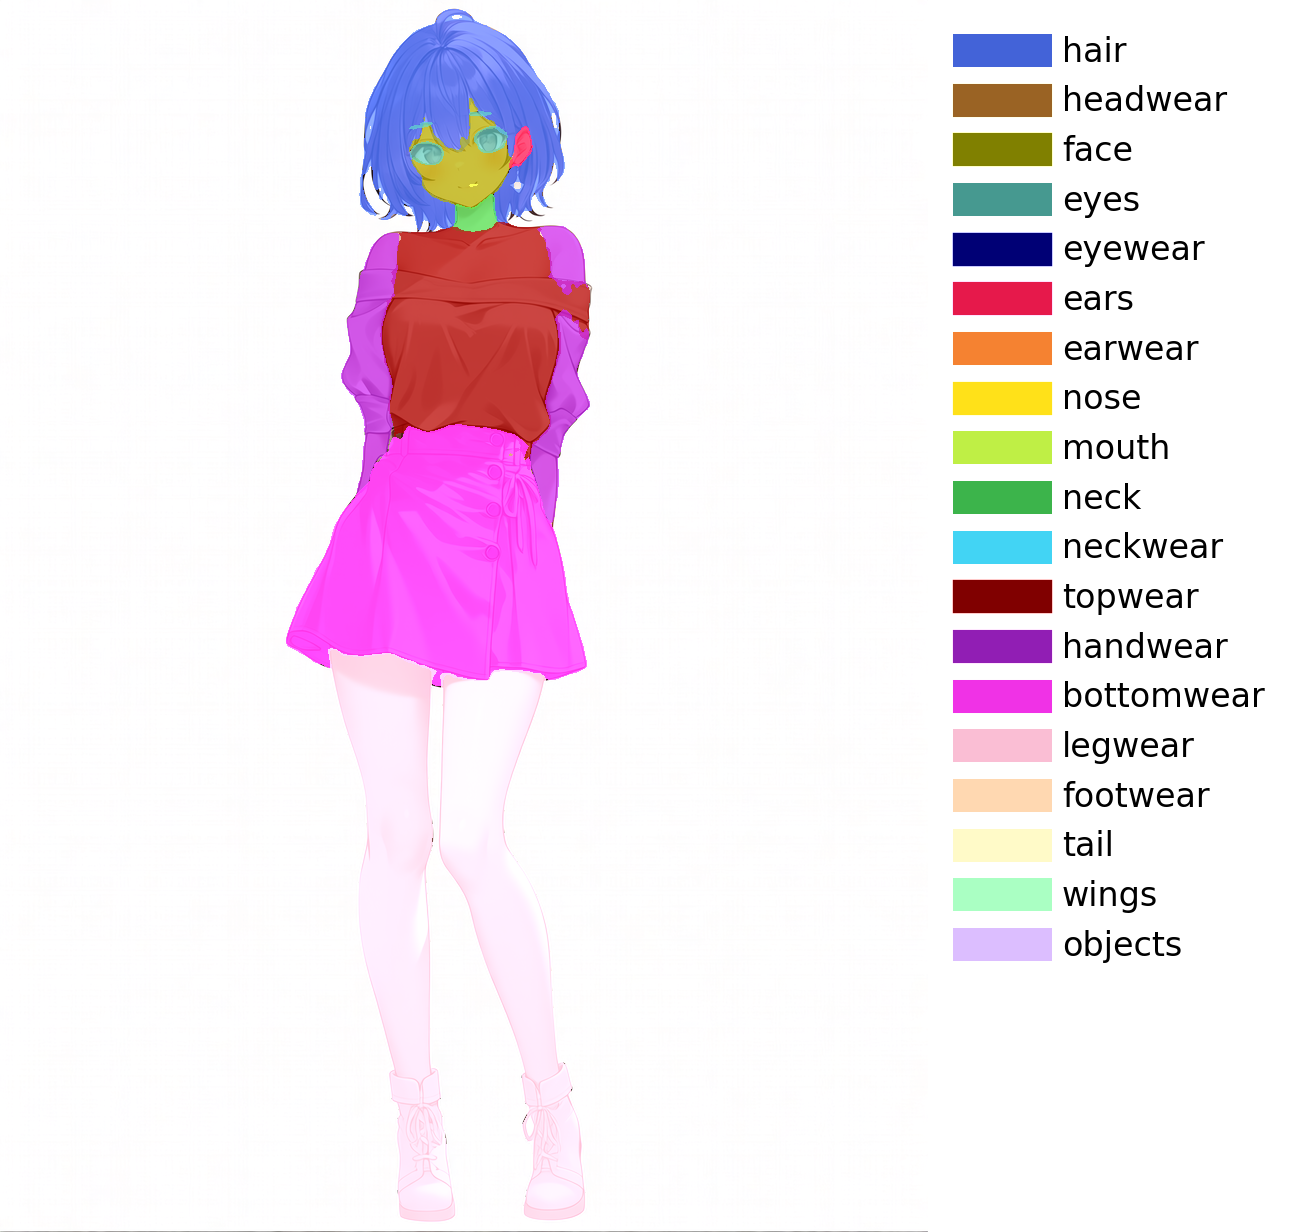

In [5]:
Image.fromarray(visualize_segs_with_labels(masks_np, img, VALID_BODY_PARTS_V2))